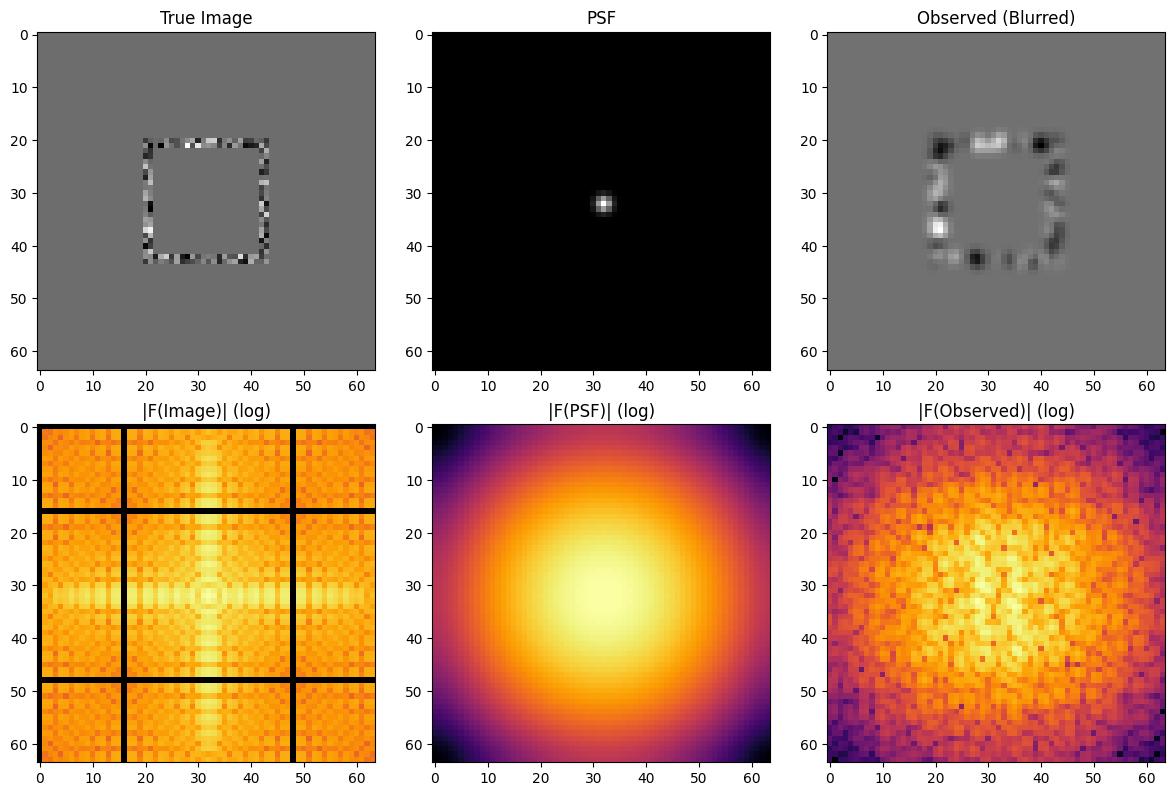

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create a toy image
# -----------------------------
N = 64

img = np.zeros((N, N))

# Parameters
top, left = 20, 20
bottom, right = 44, 44  # size = 24x24

# Top and bottom edges
img[top:top+2, left:right] = 1          # thickness = 2
img[bottom-2:bottom, left:right] = 1

# Left and right edges
img[top:bottom, left:left+2] = 1
img[top:bottom, right-2:right] = 1
# -----------------------------
# 1.5 Add background "static"
# -----------------------------
noise_level = 0.01  # tune this

background = noise_level * np.random.randn(N, N)

# combine → this is your TRUE image
img_noisy = img * background

# -----------------------------
# 2. Define a PSF (Gaussian blur)
# -----------------------------
def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

psf = gaussian_psf(N, sigma=1)
psf = np.fft.ifftshift(psf)

# -----------------------------
# 3. Convolution via FFT
# -----------------------------
def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))

observed = fft_convolve(img_noisy, psf)

# -----------------------------
# 4. Fourier transforms
# -----------------------------
F_img = np.fft.fftshift(np.fft.fft2(img))
F_psf = np.fft.fftshift(np.fft.fft2(psf))
F_obs = np.fft.fftshift(np.fft.fft2(observed))

# -----------------------------
# 5. Visualization helper
# -----------------------------
def show_all():
    plt.figure(figsize=(12, 8))

    plt.subplot(2,3,1)
    plt.title("True Image")
    plt.imshow(img_noisy, cmap='gray')

    plt.subplot(2,3,2)
    plt.title("PSF")
    plt.imshow(np.fft.fftshift(psf), cmap='gray')

    plt.subplot(2,3,3)
    plt.title("Observed (Blurred)")
    plt.imshow(observed, cmap='gray')

    plt.subplot(2,3,4)
    plt.title("|F(Image)| (log)")
    plt.imshow(np.log(np.abs(F_img)+1e-8), cmap='inferno')

    plt.subplot(2,3,5)
    plt.title("|F(PSF)| (log)")
    plt.imshow(np.log(np.abs(F_psf)+1e-8), cmap='inferno')

    plt.subplot(2,3,6)
    plt.title("|F(Observed)| (log)")
    plt.imshow(np.log(np.abs(F_obs)+1e-8), cmap='inferno')

    plt.tight_layout()
    plt.show()

show_all()

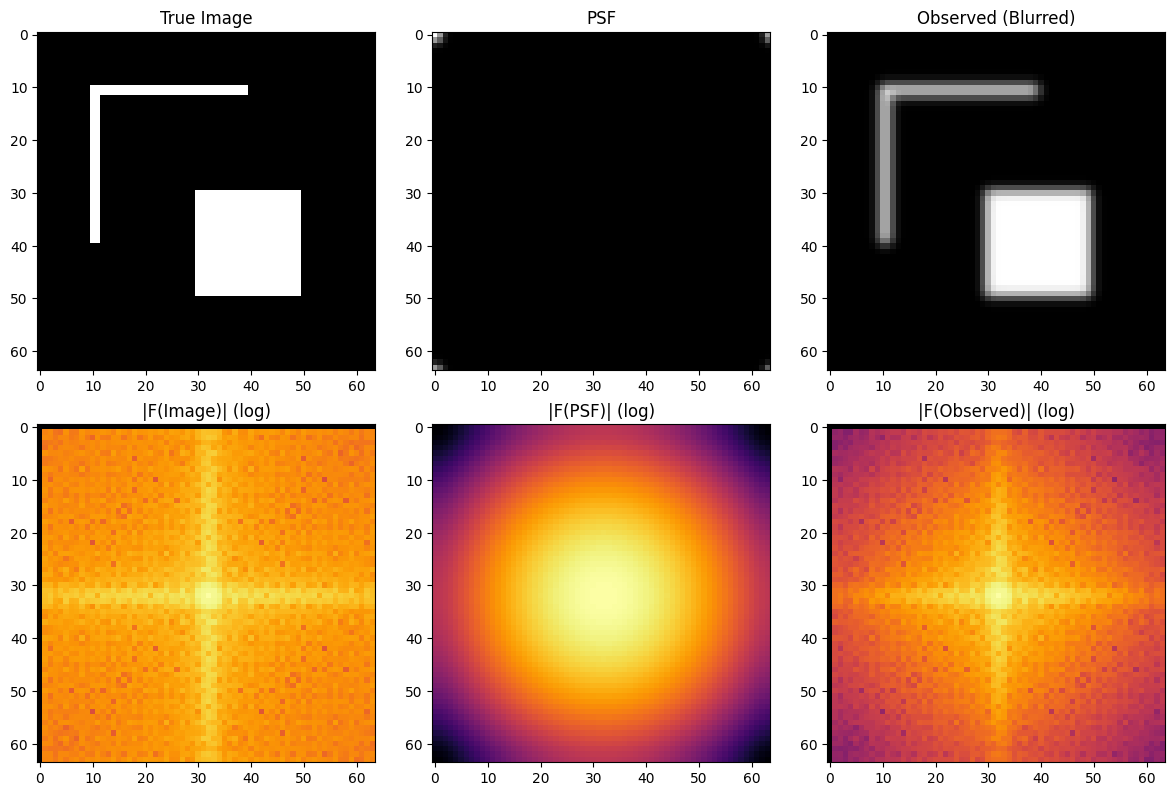

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create a toy image
# -----------------------------
N = 64

img = np.zeros((N, N))

# edges
img[10:40, 10:12] = 1
img[10:12, 10:40] = 1

# square
img[30:50, 30:50] = 1

# -----------------------------
# 1.5 Add background "static"
# -----------------------------
noise_level = 0.0  # tune this

background = noise_level * np.random.randn(N, N)

# combine → this is your TRUE image
img_noisy = img

# -----------------------------
# 2. Define a PSF (Gaussian blur)
# -----------------------------
def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

psf = gaussian_psf(N, sigma=1)
psf = np.fft.ifftshift(psf)

# -----------------------------
# 3. Convolution via FFT
# -----------------------------
def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))

observed = fft_convolve(img_noisy, psf)

# -----------------------------
# 4. Fourier transforms
# -----------------------------
F_img = np.fft.fftshift(np.fft.fft2(img))
F_psf = np.fft.fftshift(np.fft.fft2(psf))
F_obs = np.fft.fftshift(np.fft.fft2(observed))

# -----------------------------
# 5. Visualization helper
# -----------------------------
def show_all():
    plt.figure(figsize=(12, 8))

    plt.subplot(2,3,1)
    plt.title("True Image")
    plt.imshow(img_noisy, cmap='gray')

    plt.subplot(2,3,2)
    plt.title("PSF")
    plt.imshow(psf, cmap='gray')

    plt.subplot(2,3,3)
    plt.title("Observed (Blurred)")
    plt.imshow(observed, cmap='gray')

    plt.subplot(2,3,4)
    plt.title("|F(Image)| (log)")
    plt.imshow(np.log(np.abs(F_img)+1e-8), cmap='inferno')

    plt.subplot(2,3,5)
    plt.title("|F(PSF)| (log)")
    plt.imshow(np.log(np.abs(F_psf)+1e-8), cmap='inferno')

    plt.subplot(2,3,6)
    plt.title("|F(Observed)| (log)")
    plt.imshow(np.log(np.abs(F_obs)+1e-8), cmap='inferno')

    plt.tight_layout()
    plt.show()

show_all()

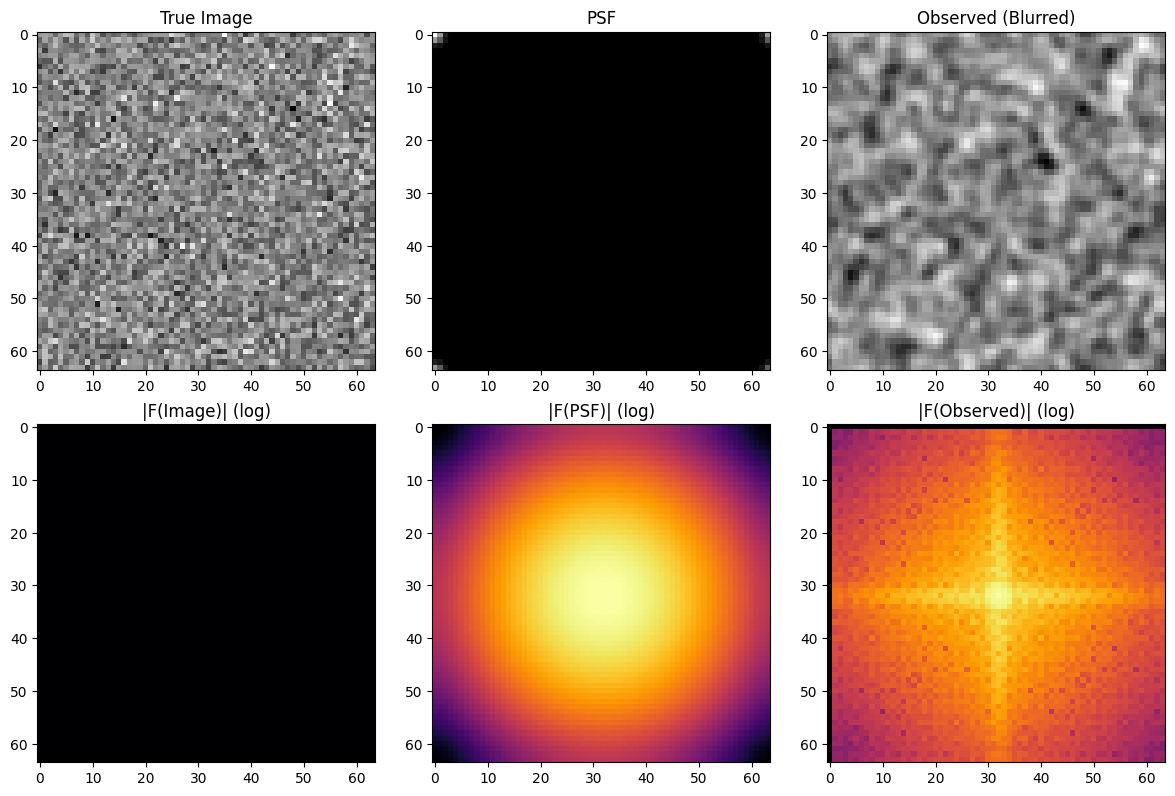

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create a toy image
# -----------------------------
N = 64

img = np.zeros((N, N))

# edges
img[10:40, 10:12] = 0
img[10:12, 10:40] = 0

# square
img[30:50, 30:50] = 0

# -----------------------------
# 1.5 Add background "static"
# -----------------------------
noise_level = 0.2  # tune this

background = noise_level * np.random.randn(N, N)

# combine → this is your TRUE image
img_noisy =  background

# -----------------------------
# 2. Define a PSF (Gaussian blur)
# -----------------------------
def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

psf = gaussian_psf(N, sigma=1)
psf = np.fft.ifftshift(psf)

# -----------------------------
# 3. Convolution via FFT
# -----------------------------
def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))

observed = fft_convolve(img_noisy, psf)

# -----------------------------
# 4. Fourier transforms
# -----------------------------
F_img = np.fft.fftshift(np.fft.fft2(img))
F_psf = np.fft.fftshift(np.fft.fft2(psf))
F_obs_diff = np.fft.fftshift(np.fft.fft2(observed))

# -----------------------------
# 5. Visualization helper
# -----------------------------
def show_all():
    plt.figure(figsize=(12, 8))

    plt.subplot(2,3,1)
    plt.title("True Image")
    plt.imshow(img_noisy, cmap='gray')

    plt.subplot(2,3,2)
    plt.title("PSF")
    plt.imshow(psf, cmap='gray')

    plt.subplot(2,3,3)
    plt.title("Observed (Blurred)")
    plt.imshow(observed, cmap='gray')

    plt.subplot(2,3,4)
    plt.title("|F(Image)| (log)")
    plt.imshow(np.log(np.abs(F_img)+1e-8), cmap='inferno')

    plt.subplot(2,3,5)
    plt.title("|F(PSF)| (log)")
    plt.imshow(np.log(np.abs(F_psf)+1e-8), cmap='inferno')

    plt.subplot(2,3,6)
    plt.title("|F(Observed)| (log)")
    plt.imshow(np.log(np.abs(F_obs)+1e-8), cmap='inferno')

    plt.tight_layout()
    plt.show()

show_all()

Epoch 1/100, Loss: 0.203807
Epoch 2/100, Loss: 0.043354
Epoch 3/100, Loss: 0.022525
Epoch 4/100, Loss: 0.008852
Epoch 5/100, Loss: 0.006664
Epoch 6/100, Loss: 0.004408
Epoch 7/100, Loss: 0.003735
Epoch 8/100, Loss: 0.003033
Epoch 9/100, Loss: 0.002243
Epoch 10/100, Loss: 0.002028
Epoch 11/100, Loss: 0.001785
Epoch 12/100, Loss: 0.001372
Epoch 13/100, Loss: 0.001820
Epoch 14/100, Loss: 0.001428
Epoch 15/100, Loss: 0.001048
Epoch 16/100, Loss: 0.000884
Epoch 17/100, Loss: 0.000815
Epoch 18/100, Loss: 0.001066
Epoch 19/100, Loss: 0.000752
Epoch 20/100, Loss: 0.000813
Epoch 21/100, Loss: 0.000721
Epoch 22/100, Loss: 0.000425
Epoch 23/100, Loss: 0.000593
Epoch 24/100, Loss: 0.000452
Epoch 25/100, Loss: 0.000237
Epoch 26/100, Loss: 0.000365
Epoch 27/100, Loss: 0.000324
Epoch 28/100, Loss: 0.000119
Epoch 29/100, Loss: 0.000132
Epoch 30/100, Loss: 0.000377
Epoch 31/100, Loss: 0.000146
Epoch 32/100, Loss: 0.000147
Epoch 33/100, Loss: 0.000081
Epoch 34/100, Loss: 0.000080
Epoch 35/100, Loss: 0.0

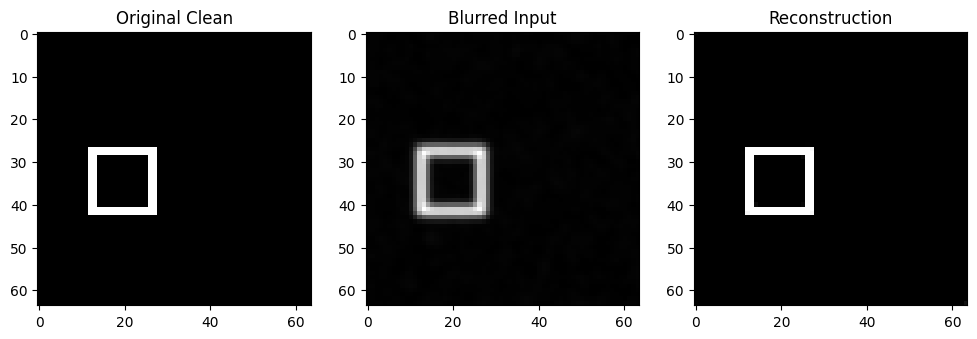

In [3]:
import numpy as np


# Generate fixed background noise once
fixed_background = noise_level * np.random.randn(N, N)

def generate_random_shape(N=64, noise_level=0.01):
    """
    Generates a random binary shape with optional Gaussian background noise.
    """
    img = np.zeros((N, N))

    # Randomly choose shape type
    shape_type = np.random.choice(['square', 'rectangle', 'line'])

    if shape_type == 'square' or shape_type == 'rectangle':
        h = np.random.randint(N//8, N//2)
        w = h if shape_type == 'square' else np.random.randint(N//8, N//2)
        top = np.random.randint(0, N - h)
        left = np.random.randint(0, N - w)
        # Hollow rectangle
        img[top:top+2, left:left+w] = 1           # top
        img[top+h-2:top+h, left:left+w] = 1       # bottom
        img[top:top+h, left:left+2] = 1           # left
        img[top:top+h, left+w-2:left+w] = 1       # right
    elif shape_type == 'line':
        orientation = np.random.choice(['horizontal', 'vertical'])
        if orientation == 'horizontal':
            row = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            col = np.random.randint(0, N - length)
            img[row:row+2, col:col+length] = 1
        else:
            col = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            row = np.random.randint(0, N - length)
            img[row:row+length, col:col+2] = 1

    # Add Gaussian background noise
    background = noise_level * np.random.randn(N, N)
    img_noisy = img + background
    img_noisy = np.clip(img_noisy, 0, None)

    return img_noisy, img  # return noisy input and clean original

def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return np.fft.ifftshift(kernel)

def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))


import torch
import torch.nn as nn
import torch.optim as optim

class DeconvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    # Hyperparameters
N = 64
sigma_psf = 1.0
noise_level = 0.02
batch_size = 16
lr = 1e-3
epochs = 100

# PSF for convolution
psf = gaussian_psf(N, sigma_psf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeconvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

for epoch in range(epochs):
    epoch_loss = 0
    for _ in range(batch_size):
        # generate random shape
        img_noisy, img_clean = generate_random_shape(N, noise_level)

        # blur it
        observed = fft_convolve(img_noisy, psf)

        # convert to torch tensors
        x = torch.tensor(observed, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        y = torch.tensor(img_clean, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/batch_size:.6f}")



# Test one example
img_noisy, img_clean = generate_random_shape(N, noise_level)
observed = fft_convolve(img_noisy, psf)

x = torch.tensor(observed, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    recon = model(x).cpu().squeeze().numpy()

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original Clean")
plt.imshow(img_clean, cmap='gray')
plt.subplot(1,3,2)
plt.title("Blurred Input")
plt.imshow(observed, cmap='gray')
plt.subplot(1,3,3)
plt.title("Reconstruction")
plt.imshow(recon, cmap='gray')
plt.show()



Epoch 1/1000, Loss: 0.184984
Epoch 2/1000, Loss: 0.031222
Epoch 3/1000, Loss: 0.029042
Epoch 4/1000, Loss: 0.014049
Epoch 5/1000, Loss: 0.010590
Epoch 6/1000, Loss: 0.006821
Epoch 7/1000, Loss: 0.005202
Epoch 8/1000, Loss: 0.004516
Epoch 9/1000, Loss: 0.003738
Epoch 10/1000, Loss: 0.003263
Epoch 11/1000, Loss: 0.001873
Epoch 12/1000, Loss: 0.002765
Epoch 13/1000, Loss: 0.001400
Epoch 14/1000, Loss: 0.001283
Epoch 15/1000, Loss: 0.001067
Epoch 16/1000, Loss: 0.000842
Epoch 17/1000, Loss: 0.000456
Epoch 18/1000, Loss: 0.000402
Epoch 19/1000, Loss: 0.000336
Epoch 20/1000, Loss: 0.000273
Epoch 21/1000, Loss: 0.000276
Epoch 22/1000, Loss: 0.000150
Epoch 23/1000, Loss: 0.000128
Epoch 24/1000, Loss: 0.000083
Epoch 25/1000, Loss: 0.000180
Epoch 26/1000, Loss: 0.000155
Epoch 27/1000, Loss: 0.000129
Epoch 28/1000, Loss: 0.000066
Epoch 29/1000, Loss: 0.000095
Epoch 30/1000, Loss: 0.000077
Epoch 31/1000, Loss: 0.000047
Epoch 32/1000, Loss: 0.000046
Epoch 33/1000, Loss: 0.000082
Epoch 34/1000, Loss

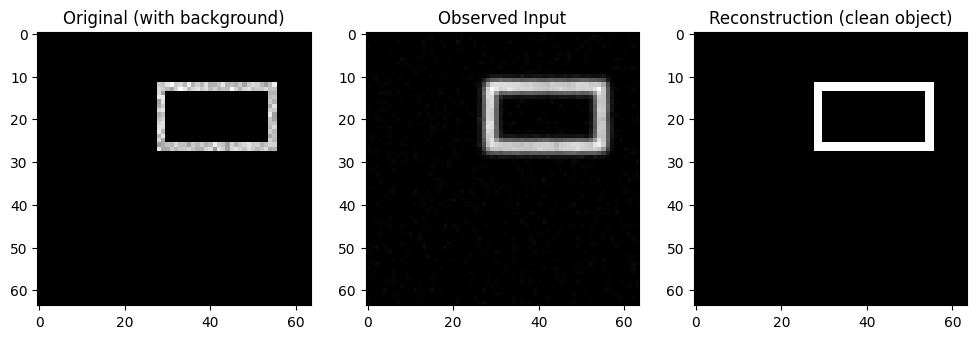

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# 1. Generate random shapes
# -----------------------------
def generate_random_shape(N=64):
    """Generates a random hollow square or line."""
    img = np.zeros((N, N))
    shape_type = np.random.choice(['square', 'rectangle', 'line'])

    if shape_type in ['square', 'rectangle']:
        h = np.random.randint(N//8, N//2)
        w = h if shape_type == 'square' else np.random.randint(N//8, N//2)
        top = np.random.randint(0, N - h)
        left = np.random.randint(0, N - w)
        # Hollow rectangle
        img[top:top+2, left:left+w] = 1
        img[top+h-2:top+h, left:left+w] = 1
        img[top:top+h, left:left+2] = 1
        img[top:top+h, left+w-2:left+w] = 1
    elif shape_type == 'line':
        orientation = np.random.choice(['horizontal', 'vertical'])
        if orientation == 'horizontal':
            row = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            col = np.random.randint(0, N - length)
            img[row:row+2, col:col+length] = 1
        else:
            col = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            row = np.random.randint(0, N - length)
            img[row:row+length, col:col+2] = 1
    return img

# -----------------------------
# 2. PSF definition
# -----------------------------
def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel /= kernel.sum()
    return np.fft.ifftshift(kernel)

def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))

# -----------------------------
# 3. CNN for deconvolution
# -----------------------------
class DeconvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# -----------------------------
# 4. Hyperparameters
# -----------------------------
N = 64
sigma_psf = 1.0
excitation_noise_level = 0.1  # variation in background excitation
sensor_noise_level = 0.01     # additive noise after convolution
batch_size = 16
lr = 1e-3
epochs = 1000

# Fixed excitation background
fixed_background = 1.0 + excitation_noise_level * np.random.randn(N, N)

# PSF
psf = gaussian_psf(N, sigma_psf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeconvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# -----------------------------
# 5. Training loop
# -----------------------------
for epoch in range(epochs):
    epoch_loss = 0
    for _ in range(batch_size):
        # generate random shape
        img_sample = generate_random_shape(N)

        # Fluorescence modulated by fixed background
        fluorescence = img_sample * fixed_background

        # Convolve with PSF
        observed = fft_convolve(fluorescence, psf)

        # Add sensor noise
        observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
        observed_noisy = np.clip(observed_noisy, 0, None)

        # Torch tensors
        x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        y = torch.tensor(img_sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/batch_size:.6f}")

# -----------------------------
# 6. Test one example
# -----------------------------
img_sample = generate_random_shape(N)

# Original fluorescence with background (for display only)
fluorescence = img_sample * fixed_background

# Observed input (convolved + sensor noise)
observed = fft_convolve(fluorescence, psf)
observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
observed_noisy = np.clip(observed_noisy, 0, None)

# Network inference
x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    recon = model(x).cpu().squeeze().numpy()

# Visualization
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original (with background)")
plt.imshow(fluorescence, cmap='gray')

plt.subplot(1,3,2)
plt.title("Observed Input")
plt.imshow(observed_noisy, cmap='gray')

plt.subplot(1,3,3)
plt.title("Reconstruction (clean object)")
plt.imshow(recon, cmap='gray')
plt.show()

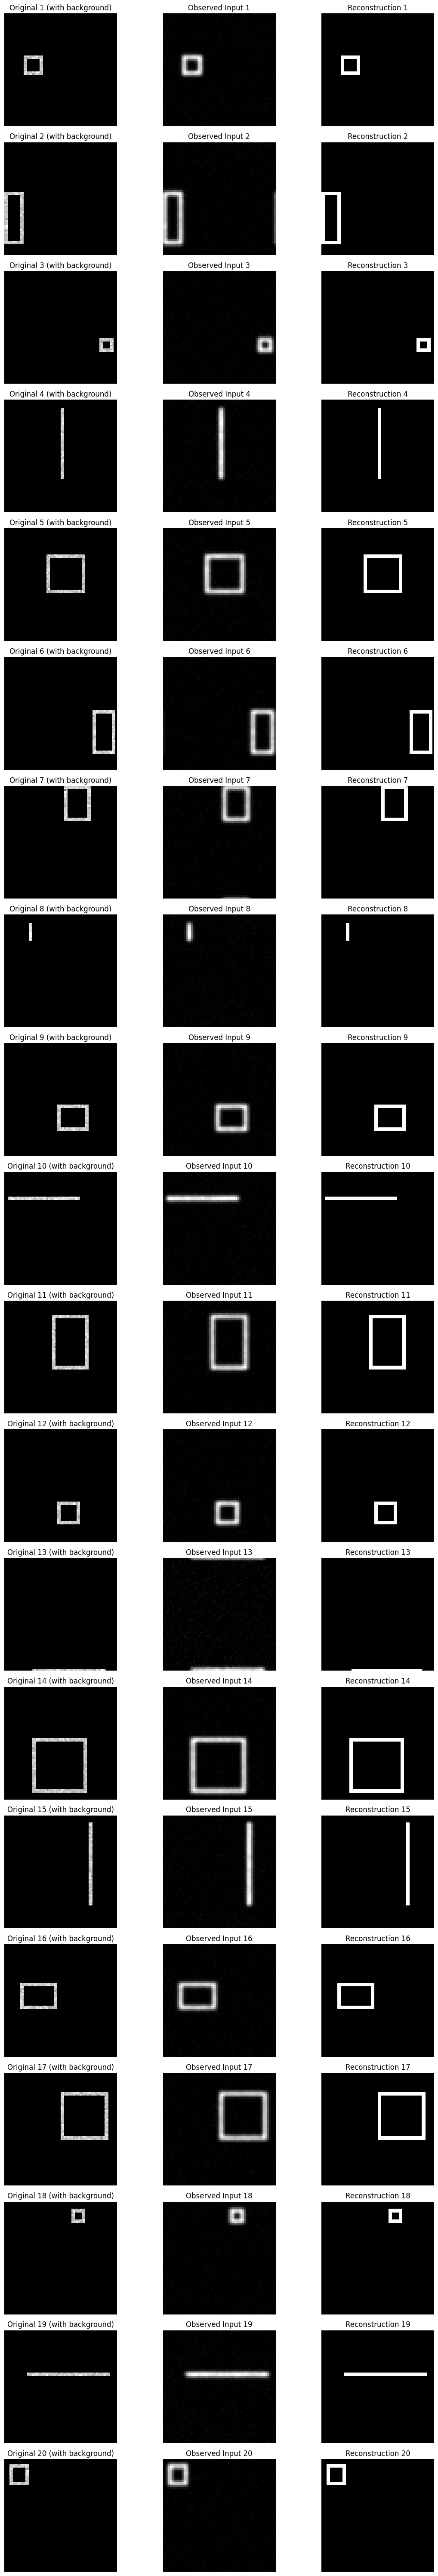

In [5]:
# Number of new test samples
num_tests = 20

plt.figure(figsize=(12, 3*num_tests))

for i in range(num_tests):
    # Generate a new random object
    img_sample = generate_random_shape(N)

    # Fluorescence (background modulated) for display
    fluorescence = img_sample * fixed_background

    # Observed input (convolved + sensor noise)
    observed = fft_convolve(fluorescence, psf)
    observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
    observed_noisy = np.clip(observed_noisy, 0, None)

    # Network inference
    x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(x).cpu().squeeze().numpy()

    # Plot
    plt.subplot(num_tests, 3, 3*i + 1)
    plt.title(f"Original {i+1} (with background)")
    plt.imshow(fluorescence, cmap='gray')
    plt.axis('off')

    plt.subplot(num_tests, 3, 3*i + 2)
    plt.title(f"Observed Input {i+1}")
    plt.imshow(observed_noisy, cmap='gray')
    plt.axis('off')

    plt.subplot(num_tests, 3, 3*i + 3)
    plt.title(f"Reconstruction {i+1}")
    plt.imshow(recon, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

Epoch 1/1000, Loss: 0.181976
Epoch 2/1000, Loss: 0.032938
Epoch 3/1000, Loss: 0.006562
Epoch 4/1000, Loss: 0.005498
Epoch 5/1000, Loss: 0.004263
Epoch 6/1000, Loss: 0.006086
Epoch 7/1000, Loss: 0.005528
Epoch 8/1000, Loss: 0.004932
Epoch 9/1000, Loss: 0.004679
Epoch 10/1000, Loss: 0.003289
Epoch 11/1000, Loss: 0.004259
Epoch 12/1000, Loss: 0.004309
Epoch 13/1000, Loss: 0.003279
Epoch 14/1000, Loss: 0.002338
Epoch 15/1000, Loss: 0.002198
Epoch 16/1000, Loss: 0.002553
Epoch 17/1000, Loss: 0.001392
Epoch 18/1000, Loss: 0.004531
Epoch 19/1000, Loss: 0.003871
Epoch 20/1000, Loss: 0.005867
Epoch 21/1000, Loss: 0.003189
Epoch 22/1000, Loss: 0.002776
Epoch 23/1000, Loss: 0.001525
Epoch 24/1000, Loss: 0.001928
Epoch 25/1000, Loss: 0.002497
Epoch 26/1000, Loss: 0.002539
Epoch 27/1000, Loss: 0.001957
Epoch 28/1000, Loss: 0.003836
Epoch 29/1000, Loss: 0.002573
Epoch 30/1000, Loss: 0.001387
Epoch 31/1000, Loss: 0.002895
Epoch 32/1000, Loss: 0.002642
Epoch 33/1000, Loss: 0.002331
Epoch 34/1000, Loss

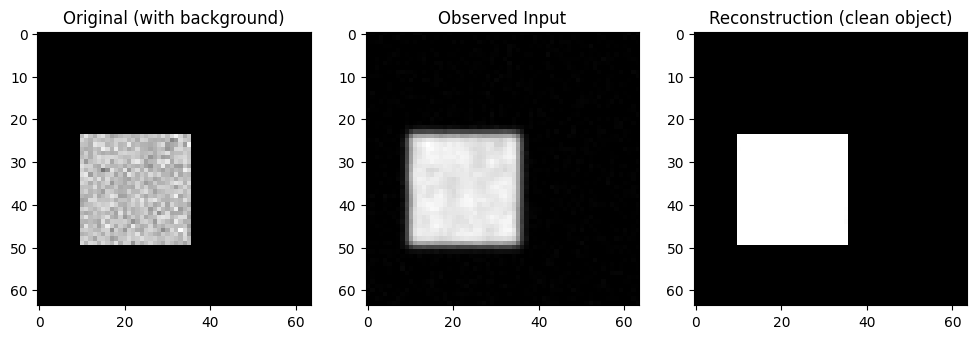

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# 1. Generate random shapes
# -----------------------------
def generate_random_shape(N=64):
    """Generates a random complex shape for microscopy simulations."""
    img = np.zeros((N, N))
    shape_type = np.random.choice([
        'filled_square', 'filled_rectangle', 'hollow_square', 'hollow_rectangle',
        'circle', 'hollow_circle', 'spiral', 'line', 'diagonal_line', 'gradient_square'
    ])

    # Random parameters
    h = np.random.randint(N//8, N//2)
    w = np.random.randint(N//8, N//2)
    top = np.random.randint(0, N - h)
    left = np.random.randint(0, N - w)

    if shape_type == 'filled_square' or shape_type == 'filled_rectangle':
        img[top:top+h, left:left+(h if shape_type=='filled_square' else w)] = 1

    elif shape_type == 'hollow_square' or shape_type == 'hollow_rectangle':
        h_w = h if shape_type=='hollow_square' else w
        img[top:top+2, left:left+h_w] = 1
        img[top+h-2:top+h, left:left+h_w] = 1
        img[top:top+h, left:left+2] = 1
        img[top:top+h, left+h_w-2:left+h_w] = 1

    elif shape_type == 'circle' or shape_type == 'hollow_circle':
        # Center and radius
        cy = np.random.randint(N//4, 3*N//4)
        cx = np.random.randint(N//4, 3*N//4)
        r = np.random.randint(N//8, N//4)
        y, x = np.ogrid[:N, :N]
        mask = (x - cx)**2 + (y - cy)**2 <= r**2
        if shape_type == 'circle':
            img[mask] = 1
        else:  # hollow circle
            mask_inner = (x - cx)**2 + (y - cy)**2 <= (r-2)**2
            img[mask & ~mask_inner] = 1

    elif shape_type == 'spiral':
        # Simple Archimedean spiral
        t = np.linspace(0, 4*np.pi, 100)
        r = np.linspace(0, N//4, 100)
        x = (N//2 + r * np.cos(t)).astype(int)
        y = (N//2 + r * np.sin(t)).astype(int)
        img[y.clip(0,N-1), x.clip(0,N-1)] = 1

    elif shape_type == 'line':
        orientation = np.random.choice(['horizontal', 'vertical'])
        if orientation == 'horizontal':
            row = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            col = np.random.randint(0, N - length)
            img[row:row+2, col:col+length] = 1
        else:
            col = np.random.randint(0, N)
            length = np.random.randint(N//8, N)
            row = np.random.randint(0, N - length)
            img[row:row+length, col:col+2] = 1

    elif shape_type == 'diagonal_line':
        for i in range(min(h, w)):
            img[top+i, left+i] = 1
            if i+1 < N: img[top+i, left+i+1] = 1

    elif shape_type == 'gradient_square':
        # Filled square with gradient intensity
        grad = np.linspace(0.1, 1.0, h)
        img[top:top+h, left:left+h] = grad[:, None]

    return img

# -----------------------------
# 2. PSF definition
# -----------------------------
def gaussian_psf(size, sigma):
    ax = np.arange(-size//2, size//2)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2)/(2*sigma**2))
    kernel /= kernel.sum()
    return np.fft.ifftshift(kernel)

def fft_convolve(a, b):
    return np.real(np.fft.ifft2(np.fft.fft2(a) * np.fft.fft2(b)))

# -----------------------------
# 3. CNN for deconvolution
# -----------------------------
class DeconvNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# -----------------------------
# 4. Hyperparameters
# -----------------------------
N = 64
sigma_psf = 1.0
excitation_noise_level = 0.1  # variation in background excitation
sensor_noise_level = 0.01     # additive noise after convolution
batch_size = 16
lr = 1e-3
epochs = 1000

# Fixed excitation background
fixed_background = 1.0 + excitation_noise_level * np.random.randn(N, N)

# PSF
psf = gaussian_psf(N, sigma_psf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeconvNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

# -----------------------------
# 5. Training loop
# -----------------------------
for epoch in range(epochs):
    epoch_loss = 0
    for _ in range(batch_size):
        # generate random shape
        img_sample = generate_random_shape(N)

        # Fluorescence modulated by fixed background
        fluorescence = img_sample * fixed_background

        # Convolve with PSF
        observed = fft_convolve(fluorescence, psf)

        # Add sensor noise
        observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
        observed_noisy = np.clip(observed_noisy, 0, None)

        # Torch tensors
        x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        y = torch.tensor(img_sample, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/batch_size:.6f}")

# -----------------------------
# 6. Test one example
# -----------------------------
img_sample = generate_random_shape(N)

# Original fluorescence with background (for display only)
fluorescence = img_sample * fixed_background

# Observed input (convolved + sensor noise)
observed = fft_convolve(fluorescence, psf)
observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
observed_noisy = np.clip(observed_noisy, 0, None)

# Network inference
x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    recon = model(x).cpu().squeeze().numpy()

# Visualization
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Original (with background)")
plt.imshow(fluorescence, cmap='gray')

plt.subplot(1,3,2)
plt.title("Observed Input")
plt.imshow(observed_noisy, cmap='gray')

plt.subplot(1,3,3)
plt.title("Reconstruction (clean object)")
plt.imshow(recon, cmap='gray')
plt.show()

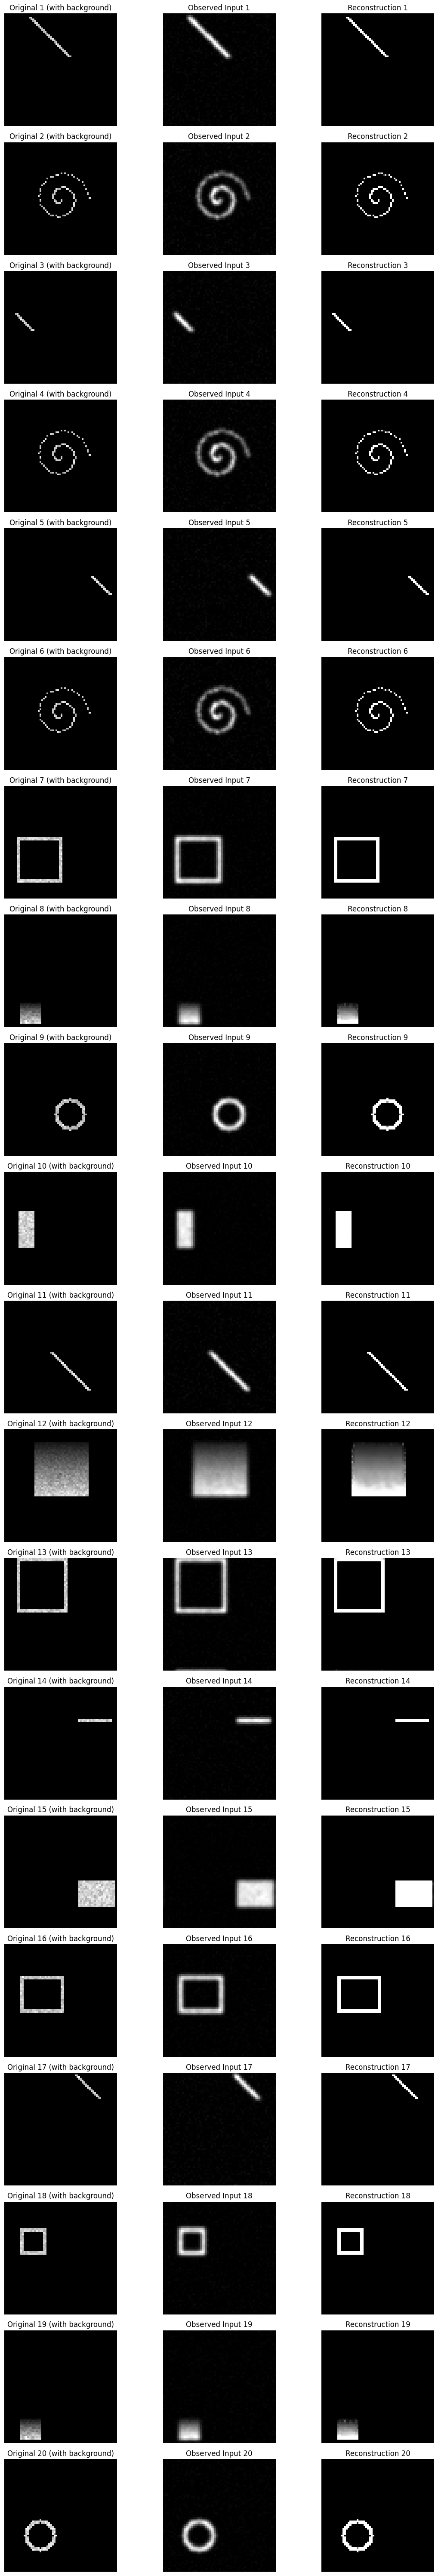

In [7]:
# Number of new test samples
num_tests = 20

plt.figure(figsize=(12, 3*num_tests))

for i in range(num_tests):
    # Generate a new random object
    img_sample = generate_random_shape(N)

    # Fluorescence (background modulated) for display
    fluorescence = img_sample * fixed_background

    # Observed input (convolved + sensor noise)
    observed = fft_convolve(fluorescence, psf)
    observed_noisy = observed + sensor_noise_level * np.random.randn(N, N)
    observed_noisy = np.clip(observed_noisy, 0, None)

    # Network inference
    x = torch.tensor(observed_noisy, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(x).cpu().squeeze().numpy()

    # Plot
    plt.subplot(num_tests, 3, 3*i + 1)
    plt.title(f"Original {i+1} (with background)")
    plt.imshow(fluorescence, cmap='gray')
    plt.axis('off')

    plt.subplot(num_tests, 3, 3*i + 2)
    plt.title(f"Observed Input {i+1}")
    plt.imshow(observed_noisy, cmap='gray')
    plt.axis('off')

    plt.subplot(num_tests, 3, 3*i + 3)
    plt.title(f"Reconstruction {i+1}")
    plt.imshow(recon, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()